In [32]:
import pandas as pd

# Target Survived 
df = pd.read_csv("/Users/bhijanbastola/Desktop/intern/Data/train-2.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Inserting and Deleting Columns and Rows

In [33]:
# Dropping a column
# dataframe.drop(<column_name>, axis)

df.drop("PassengerId", axis = 1, inplace= True)
# df.drop(["PassengerId", "Name"], axis = 1, inplace= True)

# df.drop(columns="PassengerId", inplace= False)
# df.drop(columns=["PassengerId", "Name"], inplace= False)

In [34]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [35]:
# Dropping a row
# dataframe.drop(<row_index>, axis)

# df.drop([2,4], axis = 0, inplace= False)
df.drop(index=[2,4], inplace= False).head()


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S


In [36]:
# Inserting or Replacing a columns

# Getting List of Initials
initials = [name.split(",")[-1].split(".")[0].strip() for name in df.Name]

In [37]:
df["initials"] = initials

In [38]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,initials
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr


In [39]:
# Alternative to insert
# df.insert(loc = 3, column="new_initials", value=initials)

# df.head()

In [40]:
# Insering or replacing Rows

df.loc[900,:] = [0, 3, "Braund, Mr. Owen Harris", "male", 22.0, 1, 0, "A/5 21171",7.2500 ,pd.NA, "S","Mr"]

df.tail()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,initials
887,1.0,1.0,"Graham, Miss. Margaret Edith",female,19.0,0.0,0.0,112053,30.00,B42,S,Miss
888,0.0,3.0,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1.0,2.0,W./C. 6607,23.45,NaN,S,Miss
889,1.0,1.0,"Behr, Mr. Karl Howell",male,26.0,0.0,0.0,111369,30.00,C148,C,Mr
890,0.0,3.0,"Dooley, Mr. Patrick",male,32.0,0.0,0.0,370376,7.75,NaN,Q,Mr
900,0.0,3.0,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.25,<NA>,S,Mr


## Handling Null or NaN or NA values

In [41]:
df.isna().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       688
Embarked      2
initials      0
dtype: int64

1. Removing Null Values
2. Fill something (Imputation)
3. Null as new feature ( Feature Engineering)
   
**0 -> column wise -> vertical**

**1 -> row wise -> horizontal**

In [42]:
# Removing Null Values
df.dropna(subset="Embarked", axis = 0, ignore_index=True, inplace=True)

In [43]:
df.shape

(890, 12)

In [44]:
# Null value as feature
df.Cabin = df.Cabin.notna().astype(int)

In [45]:
df.isna().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin         0
Embarked      0
initials      0
dtype: int64

In [46]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,initials
0,0.0,3.0,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,0,S,Mr
1,1.0,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,1,C,Mrs
2,1.0,3.0,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,0,S,Miss
3,1.0,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,1,S,Mrs
4,0.0,3.0,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,0,S,Mr


In [47]:
# Fill Null Values

age_median = df.Age.median()
age_median

np.float64(28.0)

<Axes: ylabel='Frequency'>

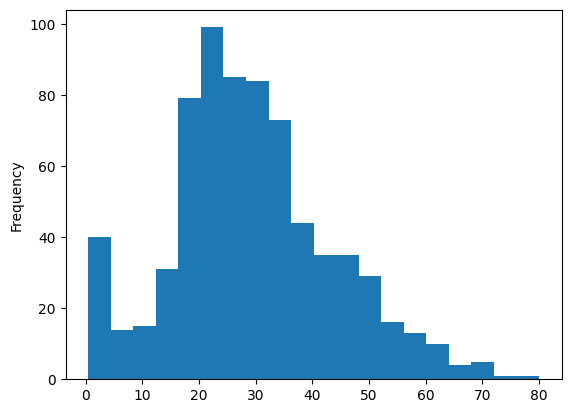

In [48]:
df.Age.plot(kind = "hist", bins = 20)

In [49]:
df_fillAge = df.copy()

df_fillAge.loc[:,"Age"] = df_fillAge.Age.fillna(value= age_median, inplace=False)

In [50]:
df_fillAge.isna().sum(axis = 0)

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Cabin       0
Embarked    0
initials    0
dtype: int64

In [51]:
df_fillAge.Age.describe()

count    890.000000
mean      29.306933
std       12.979943
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64

<Axes: ylabel='Frequency'>

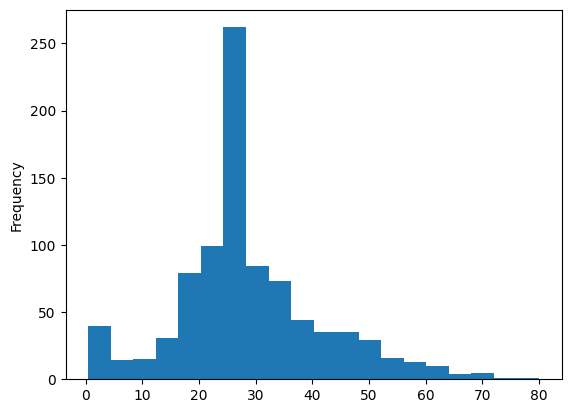

In [52]:
df_fillAge.Age.plot(kind = "hist", bins = 20)

In [53]:
# Inputation of Age wrt Gender
group_by_sex = df.groupby(by = "Sex")

In [54]:
median_ages = group_by_sex["Age"].transform("median")

In [55]:
df_fillAge_with_sex = df.copy()

df_fillAge_with_sex.loc[:,"Age"] = df_fillAge_with_sex.Age.fillna(
    value= median_ages
)

In [56]:
df_fillAge_with_sex.isna().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Cabin       0
Embarked    0
initials    0
dtype: int64

<Axes: ylabel='Frequency'>

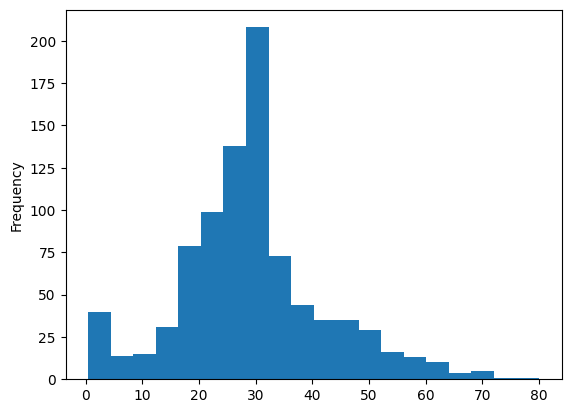

In [57]:
df_fillAge_with_sex.Age.plot(kind = "hist", bins = 20)

In [58]:
df.initials.value_counts()

initials
Mr              518
Miss            181
Mrs             124
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

### Handling Null value for Age, using initials groups.

In [59]:
group_by_initials = df.groupby(by = "initials")

In [60]:
meadin_ages = group_by_initials["Age"].transform("median")

In [61]:
df_fillAge_with_initial = df.copy()

df_fillAge_with_initial.loc[:,"Age"] = df_fillAge_with_initial.Age.fillna(
    value= meadin_ages
)

<Axes: ylabel='Frequency'>

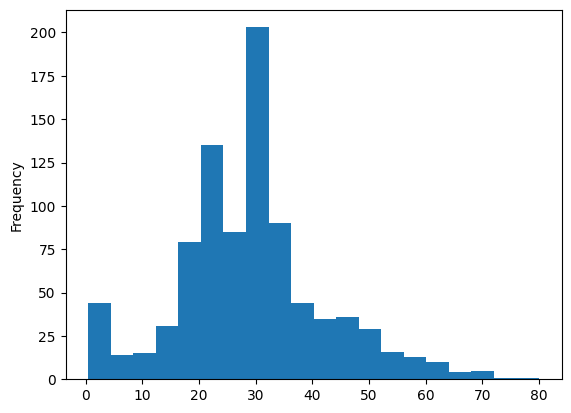

In [62]:
df_fillAge_with_initial.Age.plot(kind = "hist", bins = 20)

#Handeling NULL value for age using initials(Mr,Miss,Mrs,Master)

In [63]:
df.initials.replace(to_replace={
    "Rev":"Mr",
    "Mlle":"Mrs",
    "Major":"Mr",
    "Col":"Mr",
    "the Countess":"Mrs",
    "Capt":"Mr",
    "Ms":"Mrs",
    "Sir":"Mr",
    "Lady":"Mrs",
    "Mme":"Mrs",
    "Don":"Mr",
    "Jonkheer":"Mr",
},inplace=True)

In [64]:
df.initials.value_counts()

initials
Mr        532
Miss      181
Mrs       130
Master     40
Dr          7
Name: count, dtype: int64

In [65]:
def replace_with_gender(row):
    if row.Sex=="male":
        value="Mr"

    else:
        value="Mrs"

    return row.initials.replace("Dr",value,True)


In [68]:
df_fillAge_with_initial.duplicated().sum()

np.int64(1)

np.int64(1)